In [2]:
import numpy as np
import cv2
import torch
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("device:", device)


device: cuda


In [3]:
# 문제 1 : 모든 이미지는 중앙에 위치해야 한다., 크기가 꽉 차야한다.
# 해결 1 : 학습 데이터 증강 -> 원본이미지로 새로운 이미지 생성
# 학습용: 이동/크기/회전/기울임 증강  ← 위치·크기 변화에 강건해짐
train_tf = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.12, 0.12),
                            scale=(0.75, 1.25), shear=8, fill=0),
    transforms.ToTensor(),          # [0,1] 스케일링
])
# 평가용: 증강 없음
eval_tf = transforms.ToTensor()


train_set = datasets.MNIST("data", train=True,  download=True, transform=train_tf) #transform = train_tf에서 증가 + tensor flow
test_set  = datasets.MNIST("data", train=False, download=True, transform=eval_tf)


train_loader = DataLoader(train_set, batch_size=64, shuffle=True)


# 검증/테스트: (N,1,28,28) float32, [0,1] — 학습과 동일한 스케일
x_all = test_set.data.float().div(255.0).unsqueeze(1)  #div(355)로 스케일링, unsqueeze로 차원 맞추기
y_all = test_set.targets
x_val,  y_val  = x_all[:5000], y_all[:5000]
x_test, y_test = x_all[5000:], y_all[5000:]
print(x_val.shape, x_val.min().item(), x_val.max().item())


torch.Size([5000, 1, 28, 28]) 0.0 1.0


In [4]:
#모델 구조
#손글씨와 다르게 원본데이터 증강을 한대신 대비 파라미터를 줄임 

class CNN_model(nn.Module):
    """28 →(pool) 14 →(pool) 7 →(pool) 3  →  128*3*3 = 1152"""
    def __init__(self, n_classes=10): #신경망 층  생성
        super().__init__() #상위 오브젝트 생성(nn.Module)
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2),
            )
        self.conv1 = block(1, 32)      # 28 → 14
        self.conv2 = block(32, 64)     # 14 → 7
        self.conv3 = block(64, 128)    # 7  → 3
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128 * 3 * 3, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, n_classes),
        )


    def forward(self, x):
        x = self.conv3(self.conv2(self.conv1(x)))
        return self.head(x)


model = CNN_model().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=1e-3)
print("params:", sum(p.numel() for p in model.parameters()))  
#models.params하면 층별로 파라미터 수가 나옴 -> 한층씩 꺼내서 p를 뽑아내서 누적을 하면 전체 파라미터개수가 나오는에 약 39만개


params: 390858


In [ ]:
# 학습 함수
def train(dataloader, model, loss_fn, optimizer, device):
    model.train()
    total = 0.0
    #for 문은 dataloader의 길이 만큼 반복한다  -> 그래서 마지막에 total / len(dataloader)
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)


        optimizer.zero_grad()            # ① 기울기 초기화
        pred = model(x)                  # ② 순전파
        loss = loss_fn(pred, y)
        loss.backward()                  # ③ 역전파
        optimizer.step()                 # ④ 파라미터 갱신


        total += loss.item()             # ★ .item() — 텐서 누적 금지(메모리 누수)
    return total / len(dataloader) #전체오차를 평균한거를 반환하다


In [ ]:
@torch.no_grad()  #밑에 evaluate 함수가 no_grad() 로 작동됨  (with 대체)
def evaluate(x, y, model, loss_fn, device, batch_size=512):
    """배치 단위 평가 — 5000장을 한 번에 GPU에 올리지 않음"""
    #batch_size를 안주면 5000장을 한번에 올림 -> batch_size = 512 로 해야지 메모리 낭비가 아님
    model.eval()
    loss_sum, preds = 0.0, []
    for i in range(0, len(x), batch_size):
        xb, yb = x[i:i+batch_size].to(device), y[i:i+batch_size].to(device)
        out = model(xb)
        loss_sum += loss_fn(out, yb).item() * len(xb)   # 샘플 가중합
        preds.append(out.cpu())
    return loss_sum / len(x), torch.cat(preds)


#@torch.no_grasd() 로 대체함
    # with torch.no_grad(): # 평가 과정에서 기울기를 계산하지 않도록 설정
    #     x, y = x_val_tensor.to(device), y_val_tensor.to(device)
    #     pred = model(x)
    #     eval_loss = loss_fn(pred, y).item() # 예측값 pred와 목푯값 y 사이의 오차 계산


In [7]:
# 시각화 함수
def dl_learning_curve(tr, va):
    e = range(1, len(tr) + 1)
    plt.plot(e, tr, marker='.', label='train')
    plt.plot(e, va, marker='.', label='val')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(); plt.show()




Epoch  1 | train 0.2796 | val 0.0590
Epoch  2 | train 0.1169 | val 0.0393
Epoch  3 | train 0.0938 | val 0.0329
Epoch  4 | train 0.0813 | val 0.0269
Epoch  5 | train 0.0707 | val 0.0275
Epoch  6 | train 0.0647 | val 0.0283
Epoch  7 | train 0.0623 | val 0.0502
Epoch  8 | train 0.0577 | val 0.0211
Epoch  9 | train 0.0556 | val 0.0254
Epoch 10 | train 0.0533 | val 0.0214
Epoch 11 | train 0.0509 | val 0.0285
Epoch 12 | train 0.0489 | val 0.0237
Epoch 13 | train 0.0479 | val 0.0231
Epoch 14 | train 0.0452 | val 0.0202
Epoch 15 | train 0.0462 | val 0.0265


C:\Users\mega\AppData\Local\Temp\ipykernel_21444\995333188.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_mnist_cnn.pt", map_loc

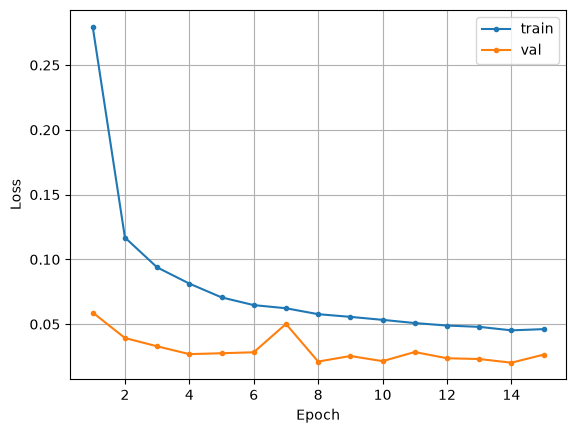

              precision    recall  f1-score   support

           0     1.0000    0.9981    0.9990       520
           1     0.9982    1.0000    0.9991       564
           2     0.9960    1.0000    0.9980       502
           3     1.0000    0.9941    0.9971       510
           4     1.0000    0.9938    0.9969       482
           5     0.9932    0.9977    0.9954       436
           6     0.9980    1.0000    0.9990       496
           7     0.9904    0.9961    0.9932       516
           8     0.9979    0.9979    0.9979       485
           9     0.9959    0.9918    0.9939       489

    accuracy                         0.9970      5000
   macro avg     0.9970    0.9970    0.9970      5000
weighted avg     0.9970    0.9970    0.9970      5000



In [8]:
# 학습
# val score가 더 낮게 나온이유: 데이터 증강 (없는 이미지를 만들어냄)
#ephoch가 15면, 모델이 15번 만들어지는데 그중에 오차가 제일 작은걸 
epochs = 15                      # 증강을 쓰면 에포크를 조금 더 주는 편이 좋음
tr_list, va_list = [], []
best = float('inf') #best -> best는 초기값으로 제일 큰값을 줌 (초기화)


for t in range(epochs):
    tr = train(train_loader, model, loss_fn, optimizer, device)
    va, _ = evaluate(x_val, y_val, model, loss_fn, device)
    tr_list.append(tr); va_list.append(va)
    print(f"Epoch {t+1:2d} | train {tr:.4f} | val {va:.4f}")


    if va < best:                # 검증 오차 최저 시점 저장
        best = va
        torch.save(model.state_dict(), "best_mnist_cnn.pt") #베스트 모델 저장
        #best_mnist_cnn.pt  이 모델안에 w가 저장되어있어서 나중에 가져다 쓰면 됨

#방금 저장했던 모델로 다시 모델 만들어라
model.load_state_dict(torch.load("best_mnist_cnn.pt", map_location=device))
dl_learning_curve(tr_list, va_list)

#logits -> 예측값이라고 생각하면됨      

_, logits = evaluate(x_test, y_test, model, loss_fn, device)
pred = logits.argmax(dim=1).numpy()
print(classification_report(y_test.numpy(), pred, digits=4))


In [15]:
# 예측값 추출하는 함수
@torch.no_grad()
def predict_digit(model, img28, device, tta=True, topk=3):
    """img28: preprocess_like_mnist 결과 (28,28) uint8"""
    model.eval()
    x = torch.tensor(img28, dtype=torch.float32).div(255.0).view(1, 1, 28, 28)


    batch = [x]
    if tta:                                   # 상하좌우 1px 이동본을 함께 평가
        for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            batch.append(torch.roll(x, shifts=(dy, dx), dims=(2, 3)))
    batch = torch.cat(batch).to(device)


    probs = torch.softmax(model(batch), dim=1).mean(dim=0).cpu().numpy()
    order = probs.argsort()[::-1][:topk]
    return int(order[0]), [(int(i), float(probs[i])) for i in order]


In [16]:
#center로 중앙이동 함수
# 중앙 이동 함수
def _center_of_mass(a):
    """scipy 없이 픽셀 질량중심 (y, x) 계산"""
    total = a.sum(dtype=np.float64)
    if total == 0:
        return a.shape[0] / 2.0, a.shape[1] / 2.0
    ys, xs = np.indices(a.shape)
    return ((ys * a).sum(dtype=np.float64) / total,
            (xs * a).sum(dtype=np.float64) / total)


In [ ]:
#원본이미지 따서 키우는 작업
#원본이미지를 MNIST 이미지로 변경하는 함수

In [ ]:
# 원본 이미지 => MNIST 함수
# 이경우 (그림판 이미지) 를 중앙에 이동시켜서 이미지 전처리하는 함수 
def preprocess_like_mnist(img, box=20, canvas=28, thicken=True, return_steps=False):
    """
    임의의 손글씨 이미지를 MNIST 규격(28x28, 검은 배경/흰 글씨, 20px 박스,
    질량중심 중앙 정렬)으로 변환한다.
    반환: uint8 (28,28)
    """
    if img is None:
        raise ValueError("이미지를 읽지 못했습니다.")
    if img.ndim == 3:                                  # 컬러면 그레이스케일
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img.astype(np.uint8)
    steps = {"0_원본": img.copy()}


    # ── 1) 배경 밝기 자동 판별 → 항상 "검은 배경 + 흰 글씨"로 통일
    #     테두리 4변의 평균 밝기로 배경색을 추정 (255-img 하드코딩 제거)
    border = np.concatenate([img[0, :], img[-1, :], img[:, 0], img[:, -1]])
    if border.mean() > 127:
        img = 255 - img
    steps["1_반전"] = img.copy()


    # ── 2) Otsu 이진화: 안티앨리어싱/압축 잡음/회색 잔상 제거
    _, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    steps["2_이진화"] = binary.copy()


    # ── 3) 획 두께 보정 (★ 축소 전에 수행해야 얇은 획이 살아남음)
    #     커널을 이미지 크기에 비례시켜 해상도와 무관하게 동작
    if thicken:
        k = int(round(min(binary.shape) / 90))
        if k >= 2:
            binary = cv2.dilate(binary, np.ones((k, k), np.uint8), iterations=1)
    steps["3_두께보정"] = binary.copy()


    # ── 4) 숫자 bounding box만 크롭 (여백 제거)
    coords = cv2.findNonZero(binary)
    if coords is None:
        raise ValueError("숫자를 찾지 못했습니다. 더 진하고 크게 그려주세요.")
    x, y, w, h = cv2.boundingRect(coords)
    digit = binary[y:y + h, x:x + w]
    steps["4_크롭"] = digit.copy()


    # ── 5) 종횡비 유지하며 긴 변을 20px로 (축소는 INTER_AREA가 정답)
    if w >= h:
        new_w, new_h = box, max(1, int(round(h * box / w)))
    else:
        new_h, new_w = box, max(1, int(round(w * box / h)))
    digit = cv2.resize(digit, (new_w, new_h), interpolation=cv2.INTER_AREA)


    # ── 6) 28x28 캔버스 중앙에 배치
    out = np.zeros((canvas, canvas), dtype=np.uint8)
    y0, x0 = (canvas - new_h) // 2, (canvas - new_w) // 2
    out[y0:y0 + new_h, x0:x0 + new_w] = digit
    steps["5_28x28배치"] = out.copy()


    # ── 7) ★ 질량중심을 캔버스 정중앙(13.5, 13.5)으로 평행이동 — MNIST 공식 규격
    cy, cx = _center_of_mass(out)
    c = (canvas - 1) / 2.0
    M = np.float32([[1, 0, round(c - cx)],
                    [0, 1, round(c - cy)]])
    out = cv2.warpAffine(out, M, (canvas, canvas),
                         flags=cv2.INTER_NEAREST, borderValue=0)
    steps["6_중심정렬"] = out.copy()


    return (out, steps) if return_steps else out


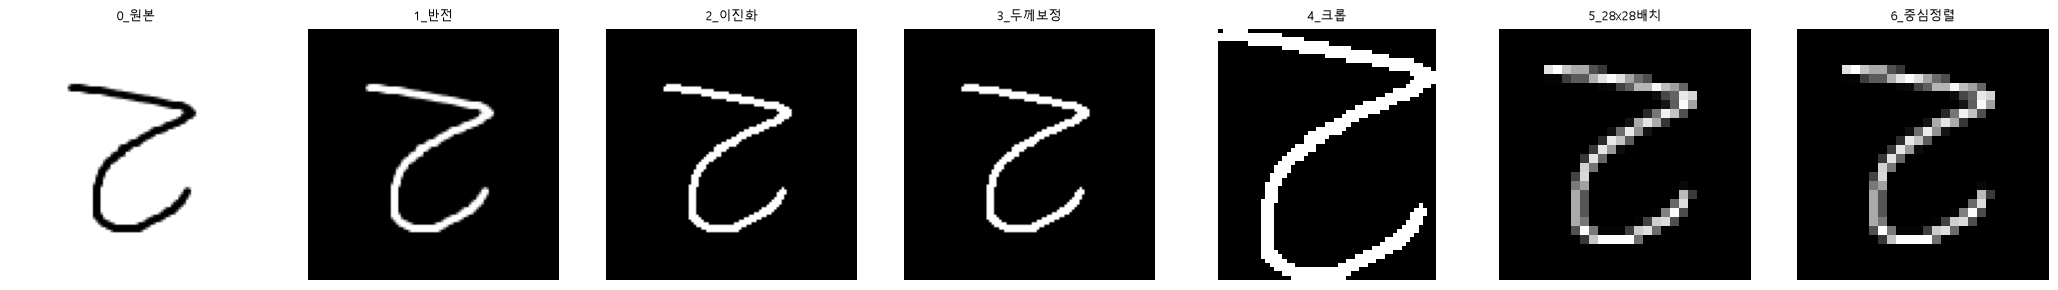

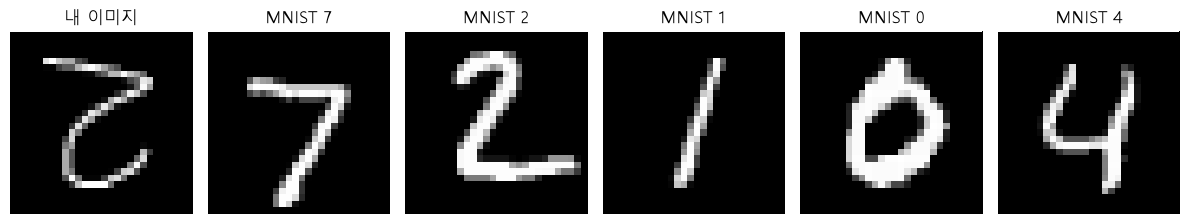

예측: 2
  2 : 79.16%
  3 : 17.25%
  8 : 2.14%


In [18]:
import warnings
warnings.filterwarnings('ignore')

img_path = "02.png"
raw = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img28, steps = preprocess_like_mnist(raw, return_steps=True)


# 전처리 단계별 확인 — 문제가 생기면 어느 단계에서 깨졌는지 바로 보임
fig, axes = plt.subplots(1, len(steps), figsize=(3 * len(steps), 3))
for ax, (name, im) in zip(axes, steps.items()):
    ax.imshow(im, cmap='gray'); ax.set_title(name, fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()


# ★ 가장 중요한 검증: 내 이미지 vs 실제 MNIST 샘플을 나란히 비교
fig, axes = plt.subplots(1, 6, figsize=(12, 2.2))
axes[0].imshow(img28, cmap='gray'); axes[0].set_title("내 이미지"); axes[0].axis('off')
for i in range(5):
    axes[i+1].imshow(test_set.data[i].numpy(), cmap='gray')
    axes[i+1].set_title(f"MNIST {test_set.targets[i].item()}"); axes[i+1].axis('off')
plt.tight_layout(); plt.show()


label, top = predict_digit(model, img28, device)
print(f"예측: {label}")
for d, p in top:
    print(f"  {d} : {p*100:.2f}%")


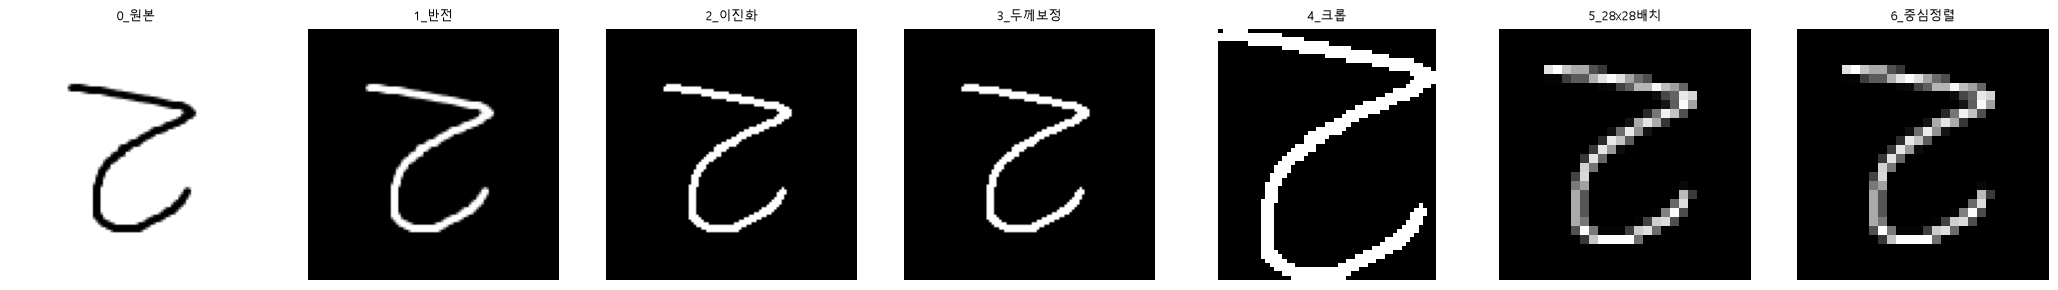

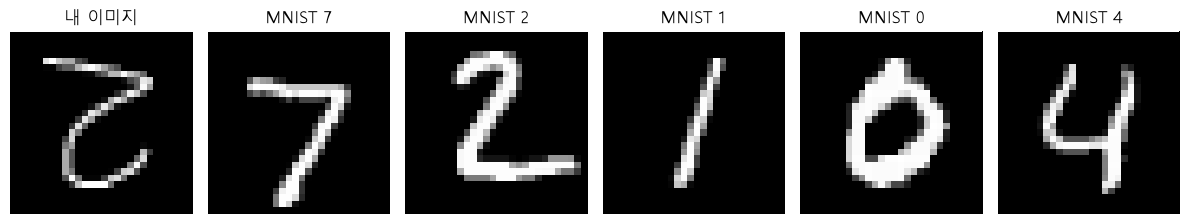

예측: 2
  2 : 79.16%
  3 : 17.25%
  8 : 2.14%


In [19]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  #


img_path = "02.png"
raw = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
img28, steps = preprocess_like_mnist(raw, return_steps=True)


# 전처리 단계별 확인 — 문제가 생기면 어느 단계에서 깨졌는지 바로 보임
fig, axes = plt.subplots(1, len(steps), figsize=(3 * len(steps), 3))
for ax, (name, im) in zip(axes, steps.items()):
    ax.imshow(im, cmap='gray'); ax.set_title(name, fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()


# ★ 가장 중요한 검증: 내 이미지 vs 실제 MNIST 샘플을 나란히 비교
fig, axes = plt.subplots(1, 6, figsize=(12, 2.2))
axes[0].imshow(img28, cmap='gray'); axes[0].set_title("내 이미지"); axes[0].axis('off')
for i in range(5):
    axes[i+1].imshow(test_set.data[i].numpy(), cmap='gray')
    axes[i+1].set_title(f"MNIST {test_set.targets[i].item()}"); axes[i+1].axis('off')
plt.tight_layout(); plt.show()


label, top = predict_digit(model, img28, device)
print(f"예측: {label}")
for d, p in top:
    print(f"  {d} : {p*100:.2f}%")
